# 실무용 시각화 레시피북

In [2]:
# 🟢환경 설정
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 한글 폰트 설정 (윈도우: Malgun Gothic, 맥: AppleGothic)
plt.rc('font', family='Malgun Gothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기 (엑셀 파일명이 public_data.xlsx라고 가정)
df = pd.read_excel('public_business_data.xlsx')

print("✅ 데이터 로드 완료! 상위 5행을 확인합니다.")
display(df.head())

✅ 데이터 로드 완료! 상위 5행을 확인합니다.


,프로젝트ID,부서,지역,예산(백만원),집행액(백만원),만족도,상태,시작일
0,PJ-1000,인프라사업부,강원,202.0,191,69.8,진행중,2023-06-10
1,PJ-1001,고객지원부,경상,535.0,556,89.6,진행중,2023-01-16
2,PJ-1002,디지털혁신단,경기,960.0,875,95.2,완료,2024-05-07
3,PJ-1003,환경안전부,경상,370.0,276,65.6,진행중,2024-03-01
4,PJ-1004,인프라사업부,충청,NaN,134,54.0,계획,2023-04-18


In [ ]:
# 🟢 데이터 정제 (결측치 해결)
# 1. 예산이 비어있으면 0으로 채우기
df['예산(백만원)'] = df['예산(백만원)'].fillna(0)

# 2. 만족도가 비어있으면 평균값으로 채우기
avg_sat = df['만족도'].mean()
df['만족도'] = df['만족도'].fillna(avg_sat)

# 3. 상태가 비어있으면 '미분류'로 채우기
df['상태'] = df['상태'].fillna('미분류')

print("✅ 결측치 정제가 완료되었습니다.")

# 🟢3단계: 새로운 지표 만들기 (집행률 & 시작월)
# 집행률 계산 (예산이 0인 경우 대비하여 에러 방지)
df['집행률'] = (df['집행액(백만원)'] / df['예산(백만원)'] * 100).replace([np.inf, -np.inf], 0).fillna(0)

# 시작일을 '월' 단위로 추출
df['시작월'] = pd.to_datetime(df['시작일']).dt.strftime('%Y-%m')

print("✅ 시각화용 신규 지표 생성 완료!")

✅ 결측치 정제가 완료되었습니다.
✅ 시각화용 신규 지표 생성 완료!


C:\Users\miran\AppData\Local\Temp\ipykernel_122008\2928044057.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_data.values, y=dept_data.index, palette='magma')


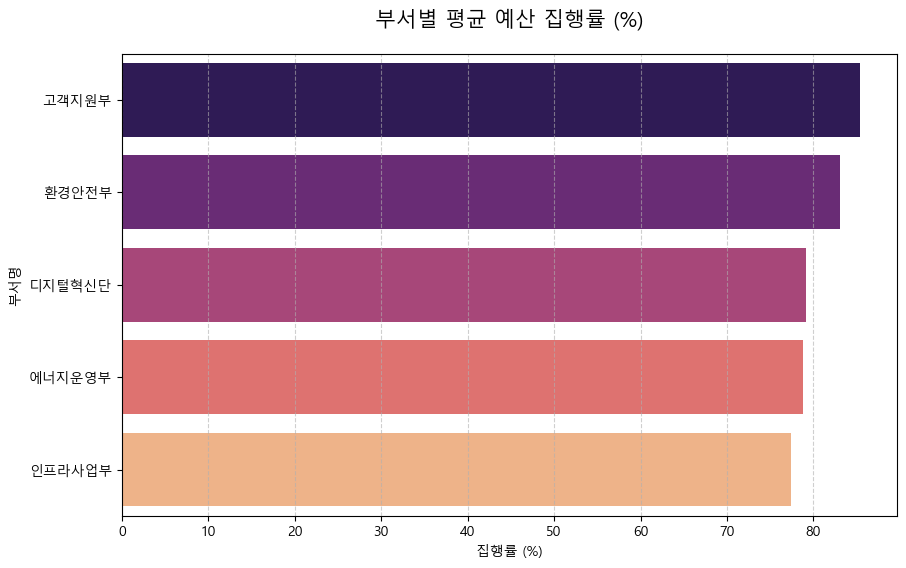

In [ ]:
# 🟢1. 막대 그래프: [비교] 부서별 평균 집행률
plt.figure(figsize=(10, 6))

# 부서별 평균 계산 및 정렬
dept_data = df.groupby('부서')['집행률'].mean().sort_values(ascending=False)

sns.barplot(x=dept_data.values, y=dept_data.index, palette='magma')

plt.title('부서별 평균 예산 집행률 (%)', fontsize=15, pad=20)
plt.xlabel('집행률 (%)')
plt.ylabel('부서명')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

C:\Users\miran\AppData\Local\Temp\ipykernel_122008\1015233124.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='지역', y='만족도', data=df, palette='Set3')


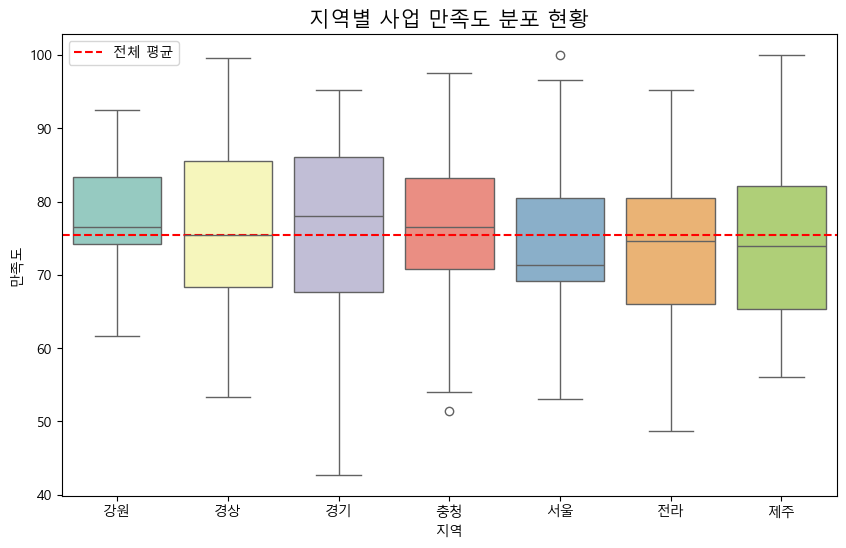

In [ ]:
# 🟢2. 박스 플롯: [분포] 지역별 만족도
plt.figure(figsize=(10, 6))

sns.boxplot(x='지역', y='만족도', data=df, palette='Set3')

plt.title('지역별 사업 만족도 분포 현황', fontsize=15)
plt.axhline(df['만족도'].mean(), color='red', linestyle='--', label='전체 평균') # 평균선 추가
plt.legend()

plt.show()

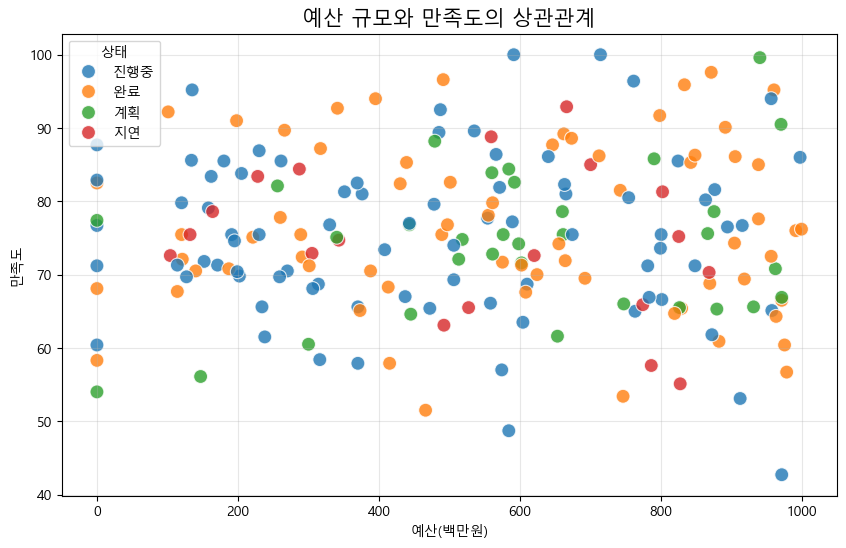

In [ ]:
# 🟢3. 산점도: [관계] 예산과 만족도의 상관관계 - 숫자 2개 이상
# "돈을 많이 쓴 사업이 과연 만족도도 높을까?"라는 질문에 답.
plt.figure(figsize=(10, 6))

sns.scatterplot(x='예산(백만원)', y='만족도', hue='상태', s=100, data=df, alpha=0.8)

plt.title('예산 규모와 만족도의 상관관계', fontsize=15)
plt.grid(True, alpha=0.3)

plt.show()

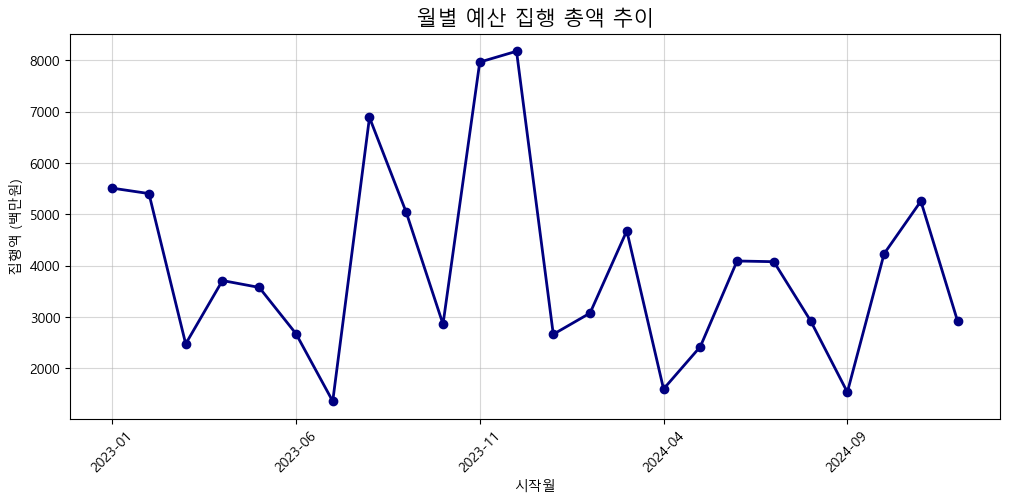

In [ ]:
# 🟢4. 선 그래프: [추세] 월별 집행 추이
# "예산 집행이 특정 시기에 몰려있는가?"를 파악

plt.figure(figsize=(12, 5))

# 월별 합계 계산
monthly_spending = df.groupby('시작월')['집행액(백만원)'].sum()

monthly_spending.plot(kind='line', marker='o', color='navy', linewidth=2)

plt.title('월별 예산 집행 총액 추이', fontsize=15)
plt.ylabel('집행액 (백만원)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)

plt.show()

In [8]:
# 🟢[저장] 고해상도 보고서용 이미지 추출🟢
# 그래프 코드를 다 쓰고 plt.show() 하기 직전에 넣으세요!
plt.savefig('2026_분기보고서_그래프.png', 
            dpi=300,            # 고해상도 설정 (인쇄용)
            bbox_inches='tight' # 여백 최소화
           )
print("💾 이미지가 현재 폴더에 저장되었습니다.")

💾 이미지가 현재 폴더에 저장되었습니다.


<Figure size 640x480 with 0 Axes>

[체크리스트]
1. 데이터 전처리 (빈 문자열""이나 NaN이 '기타'로 바뀌었는지 확인)
2. 한글이 나오는가? (폰트 설정 확인)
3. 제목과 축 이름이 있는가? (누가 봐도 무엇인지 알 수 있게)
4. 색상이 너무 화려하진 않은가? (공공기관 보고서는 가독성이 최우선)

Index(['프로젝트ID', '부서', '지역', '예산(백만원)', '집행액(백만원)', '만족도', '상태', '시작일', '집행률',
       '시작월'],
      dtype='str')


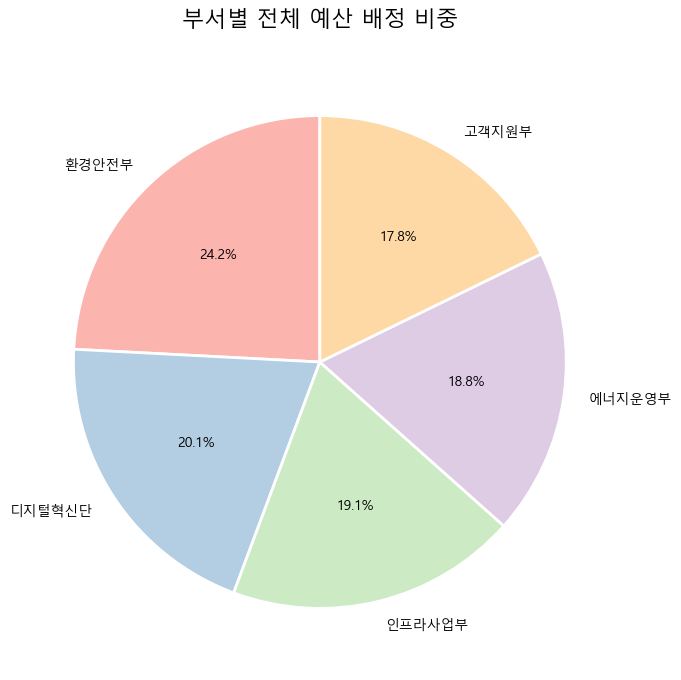

In [ ]:
#🟢 5. 파이차트: [비중] 부서별 예산 점유율 //Matplotlib만 가능
# 1. 데이터 집계 (부서별 예산 합계) 
dept_budget = df.groupby('부서')['예산(백만원)'].sum().sort_values(ascending=False)
print(df.columns) #컬럼 확인
# 2. 그래프 그리기
plt.figure(figsize=(8, 8))
plt.rc('font', family='Malgun Gothic') 

# 파이 차트 실행
plt.pie(dept_budget.values, 
        labels=dept_budget.index, #각 조각 라벨 설정
        autopct='%1.1f%%',      # 소수점 첫째자리까지 비율 표시
        startangle=90,          # 시작 각도를 12시 방향으로
        colors=plt.cm.Pastel1.colors, # 파스텔톤 색상 적용
        wedgeprops={'edgecolor': 'w', 'linewidth': 2}) # 조각 사이 간격

plt.title('부서별 전체 예산 배정 비중', fontsize=16, pad=20)
plt.show()